# 09 — Final Evaluation · YOLOv11l-seg (Global Threshold · conf=0.25)

Notebook ini dijalankan **lokal** (CPU cukup, tidak butuh GPU).

Evaluasi **satu model final**: `yolov11l-seg` hasil pipeline Stage 2 + Optuna.
Tidak ada perbandingan antar model — model sudah dipilih, ini adalah laporan performa resmi.

**Threshold mode: GLOBAL** — `conf = 0.25` untuk semua kelas.

Sections:
1. Overall segmentation metrics (val + test)
2. Per-class segmentation performance
3. Class coverage per image — **core metric NutriVision**
4. Coverage summary & distribution
5. Per-class presence coverage
6. Missing-class analysis
7. False-positive analysis
8. Instance-level performance (IoU matching)
9. Qualitative samples — visualisasi prediksi
10. Go/No-Go verdict & ringkasan


## 0. Setup

In [15]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from ultralytics import YOLO

try:
    from shapely.geometry import Polygon
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shapely"])
    from shapely.geometry import Polygon

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ── Project layout ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(r"D:\PREP_INTERN\nutrivision_pro")

DATASET_DIR  = PROJECT_ROOT / "datasets" / "clean_v2"
MODEL_PATH   = PROJECT_ROOT / "models" / "production" / "yolov11l_seg_v2_final.pt"

DATA_YAML       = DATASET_DIR  / "data.yaml"
VAL_IMAGES_DIR  = DATASET_DIR  / "valid"   / "images"
VAL_LABELS_DIR  = DATASET_DIR  / "valid"   / "labels"
TEST_IMAGES_DIR = DATASET_DIR  / "test"    / "images"
TEST_LABELS_DIR = DATASET_DIR  / "test"    / "labels"


# ── Confidence ────────────────────────────────────────────────────────────────
GLOBAL_CONF = 0.25
CONF_MODE   = "global"
IOU_MATCH   = 0.5

# ── Output dirs ───────────────────────────────────────────────────────────────
RESULTS_DIR = PROJECT_ROOT / "results" / "v2_final"
DIRS = {
    "metrics":        RESULTS_DIR / "metrics",
    "per_class":      RESULTS_DIR / "per_class",
    "class_coverage": RESULTS_DIR / "class_coverage",
    "instance":       RESULTS_DIR / "instance",
    "qualitative":    RESULTS_DIR / "qualitative",
    "summary":        RESULTS_DIR / "summary",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert MODEL_PATH.exists(),      f"Model tidak ditemukan: {MODEL_PATH}"
assert DATA_YAML.exists(),       f"data.yaml tidak ditemukan: {DATA_YAML}"
assert VAL_IMAGES_DIR.exists(),  f"Val images tidak ditemukan"
assert TEST_IMAGES_DIR.exists(), f"Test images tidak ditemukan"

IMAGE_EXTS     = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
VAL_IMG_PATHS  = sorted(p for p in VAL_IMAGES_DIR.rglob("*")  if p.suffix.lower() in IMAGE_EXTS)
TEST_IMG_PATHS = sorted(p for p in TEST_IMAGES_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS)

print(f"Project root : {PROJECT_ROOT}")
print(f"Model        : {MODEL_PATH}  ({MODEL_PATH.stat().st_size/1024**2:.1f} MB)")
print(f"Val images   : {len(VAL_IMG_PATHS)}")
print(f"Test images  : {len(TEST_IMG_PATHS)}")
print(f"Results dir  : {RESULTS_DIR}")


Project root : D:\PREP_INTERN\nutrivision_pro
Model        : D:\PREP_INTERN\nutrivision_pro\models\production\yolov11l_seg_v2_final.pt  (53.3 MB)
Val images   : 64
Test images  : 63
Results dir  : D:\PREP_INTERN\nutrivision_pro\results\v2_final


## 1. Load model

In [16]:
model       = YOLO(str(MODEL_PATH))
class_names = list(model.names.values())
num_classes = len(class_names)
total_params = sum(p.numel() for p in model.model.parameters())

print(f"Model        : YOLOv11l-seg (final)")
print(f"Parameters   : {total_params:,}")
print(f"Classes ({num_classes}) : {class_names}")


Model        : YOLOv11l-seg (final)
Parameters   : 27,627,482
Classes (14) : ['beef', 'chicken', 'egg', 'fish', 'fruit', 'noodles', 'pork', 'rice', 'sambal', 'shrimp', 'squid', 'tempeh', 'tofu', 'vegetable']


## Run Time Yaml

In [17]:

import yaml

RUNTIME_DATA_YAML = PROJECT_ROOT / "datasets" / "clean_v2" / "data_runtime.yaml"

runtime_config = {
    "path":  str(DATASET_DIR).replace("\\", "/"),
    "train": str(DATASET_DIR / "train" / "images").replace("\\", "/"),
    "val":   str(DATASET_DIR / "valid" / "images").replace("\\", "/"),
    "test":  str(DATASET_DIR / "test"  / "images").replace("\\", "/"),
    "nc":    14,
    "names": [
        "beef", "chicken", "egg", "fish", "fruit",
        "noodles", "pork", "rice", "sambal", "shrimp",
        "squid", "tempeh", "tofu", "vegetable"
    ],
}

RUNTIME_DATA_YAML.write_text(
    yaml.safe_dump(runtime_config, sort_keys=False, allow_unicode=True),
    encoding="utf-8"
)

# Override DATA_YAML ke yang runtime
DATA_YAML = RUNTIME_DATA_YAML

print(f"Runtime YAML: {DATA_YAML}")
print(DATA_YAML.read_text(encoding="utf-8"))

Runtime YAML: D:\PREP_INTERN\nutrivision_pro\datasets\clean_v2\data_runtime.yaml
path: D:/PREP_INTERN/nutrivision_pro/datasets/clean_v2
train: D:/PREP_INTERN/nutrivision_pro/datasets/clean_v2/train/images
val: D:/PREP_INTERN/nutrivision_pro/datasets/clean_v2/valid/images
test: D:/PREP_INTERN/nutrivision_pro/datasets/clean_v2/test/images
nc: 14
names:
- beef
- chicken
- egg
- fish
- fruit
- noodles
- pork
- rice
- sambal
- shrimp
- squid
- tempeh
- tofu
- vegetable



## Helper functions

In [18]:
def load_gt_annotations(label_path):
    annotations = []
    if not label_path.exists():
        return annotations
    for line in label_path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) < 7:
            continue
        class_id = int(parts[0])
        if class_id >= num_classes:
            continue
        coords = list(map(float, parts[1:]))
        points = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]
        try:
            poly = Polygon(points)
            if not poly.is_valid:
                poly = poly.buffer(0)
        except Exception:
            continue
        annotations.append({
            "class_id":   class_id,
            "class_name": class_names[class_id],
            "polygon":    poly,
        })
    return annotations


def run_prediction(image_path, conf=GLOBAL_CONF):
    result = model.predict(image_path, conf=conf, verbose=False)[0]
    predictions = []
    if result.boxes is None:
        return predictions
    masks = result.masks.xyn if result.masks is not None else [None] * len(result.boxes)
    for cls_t, conf_t, mask_xy in zip(result.boxes.cls, result.boxes.conf, masks):
        class_id = int(cls_t.item())
        poly = None
        if mask_xy is not None and len(mask_xy) >= 3:
            try:
                poly = Polygon(mask_xy.tolist())
                if not poly.is_valid:
                    poly = poly.buffer(0)
            except Exception:
                poly = None
        predictions.append({
            "class_id":   class_id,
            "class_name": class_names[class_id],
            "confidence": float(conf_t.item()),
            "polygon":    poly,
        })
    return predictions


def polygon_iou(poly_a, poly_b):
    if poly_a is None or poly_b is None:
        return 0.0
    if not poly_a.is_valid or not poly_b.is_valid:
        return 0.0
    if poly_a.area == 0 or poly_b.area == 0:
        return 0.0
    inter = poly_a.intersection(poly_b).area
    union = poly_a.area + poly_b.area - inter
    return inter / union if union > 0 else 0.0


## 2. Overall segmentation metrics (val + test)

In [19]:
overall_rows = {}
val_results  = {}

for split_name in ("val", "test"):
    print(f"\nEvaluating split={split_name} ...")
    result = model.val(
        data    = str(DATA_YAML),
        split   = split_name,
        imgsz   = 640,
        plots   = False,
        verbose = False,
    )
    val_results[split_name] = result
    overall_rows[split_name] = {
        "split":          split_name,
        "model":          "yolov11l-seg",
        "conf_mode":      CONF_MODE,
        "global_conf":    GLOBAL_CONF,
        "mask_precision": round(float(result.seg.mp),    4),
        "mask_recall":    round(float(result.seg.mr),    4),
        "mask_mAP50":     round(float(result.seg.map50), 4),
        "mask_mAP50-95":  round(float(result.seg.map),   4),
        "box_precision":  round(float(result.box.mp),    4),
        "box_recall":     round(float(result.box.mr),    4),
        "box_mAP50":      round(float(result.box.map50), 4),
        "box_mAP50-95":   round(float(result.box.map),   4),
    }

overall_df = pd.DataFrame(list(overall_rows.values()))
overall_df.to_csv(DIRS["metrics"] / "overall_metrics.csv", index=False)
display(overall_df)



Evaluating split=val ...
Ultralytics 8.4.147  Python-3.13.5 torch-2.14.0+cu132 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)


YOLO11l-seg summary (fused): 203 layers, 27,595,386 parameters, 0 gradients, 132.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 788.5254.1 MB/s, size: 61.1 KB)
val: Scanning D:\PREP_INTERN\nutrivision_pro\datasets\clean_v2\valid\labels.cache... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 11.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0it/s 3.8s1.4ss
                   all         64        664      0.634      0.437      0.493      0.404      0.613       0.42      0.471      0.374
Speed: 1.4ms preprocess, 53.2ms inference, 0.0ms loss, 1.8ms postprocess per image

Evaluating split=test ...
Ultralytics 8.4.147  Python-3.13.5 torch-2.14.0+cu132 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11l-seg summary (fused): 203 layers, 27,595,386 parameters, 0 gradients, 132.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1085.03

,split,model,conf_mode,global_conf,mask_precision,mask_recall,mask_mAP50,mask_mAP50-95,box_precision,box_recall,box_mAP50,box_mAP50-95
0,val,yolov11l-seg,global,0.25,0.6130,0.4203,0.4712,0.3738,0.6344,0.4366,0.4926,0.4045
1,test,yolov11l-seg,global,0.25,0.5077,0.3390,0.3461,0.2628,0.5667,0.3635,0.3820,0.3032


## 3. Per-class segmentation metrics

In [20]:
per_class_rows = {}

for split_name, result in val_results.items():
    indices = [int(i) for i in np.asarray(result.seg.ap_class_index).tolist()]
    p_arr   = np.asarray(result.seg.p)
    r_arr   = np.asarray(result.seg.r)
    ap50    = np.asarray(result.seg.ap50)
    ap      = np.asarray(result.seg.ap)
    rows = []
    for pos, class_id in enumerate(indices):
        prec = float(p_arr[pos]) if pos < len(p_arr) else None
        rec  = float(r_arr[pos]) if pos < len(r_arr) else None
        f1   = (2*prec*rec/(prec+rec)) if (prec and rec and (prec+rec) > 0) else None
        rows.append({
            "class_id":   class_id,
            "class_name": class_names[class_id],
            "precision":  round(prec, 4) if prec is not None else None,
            "recall":     round(rec,  4) if rec  is not None else None,
            "f1":         round(f1,   4) if f1   is not None else None,
            "mAP50":      round(float(ap50[pos]), 4) if pos < len(ap50) else None,
            "mAP50-95":   round(float(ap[pos]),   4) if pos < len(ap)   else None,
        })
    df = pd.DataFrame(rows).sort_values("mAP50-95", ascending=False).reset_index(drop=True)
    per_class_rows[split_name] = df
    df.to_csv(DIRS["per_class"] / f"per_class_{split_name}.csv", index=False)

print("=== TEST SET ===")
display(per_class_rows["test"])


=== TEST SET ===


,class_id,class_name,precision,recall,f1,mAP50,mAP50-95
0,3,fish,0.6602,0.4545,0.5384,0.6189,0.5663
1,4,fruit,0.6210,0.6063,0.6135,0.6071,0.4823
2,7,rice,0.7334,0.5500,0.6286,0.5694,0.4719
3,2,egg,0.4629,0.5278,0.4932,0.4727,0.3754
4,9,shrimp,0.4243,0.4916,0.4555,0.4875,0.3327
5,5,noodles,0.4787,0.5833,0.5259,0.5503,0.2844
6,0,beef,0.2549,0.3529,0.2960,0.2576,0.2293
7,6,pork,0.6700,0.2077,0.3171,0.2856,0.1872
8,13,vegetable,0.4374,0.2658,0.3306,0.2548,0.1748
9,10,squid,0.4901,0.1667,0.2487,0.1731,0.1373


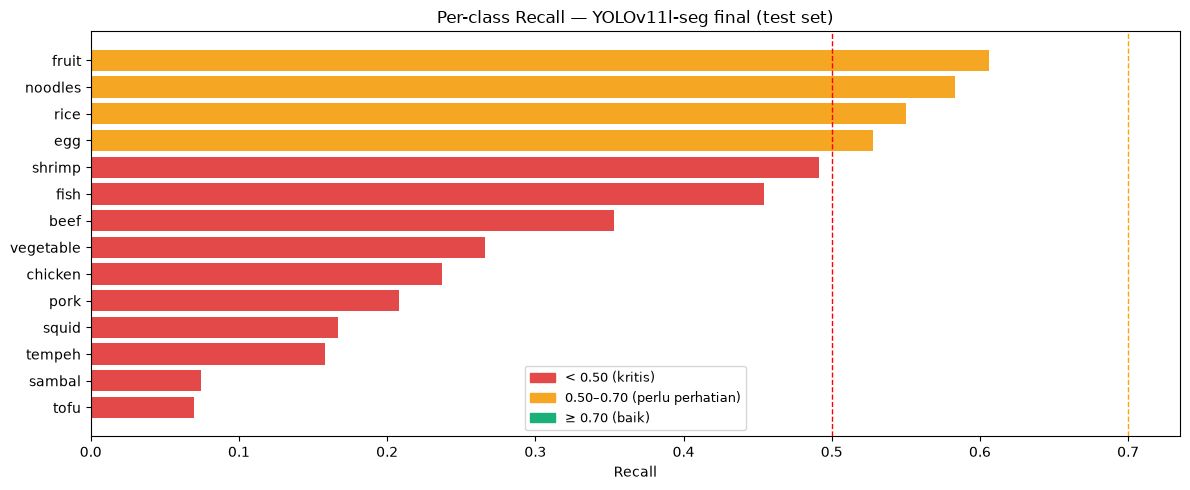

In [21]:
# ── Recall bar chart ──────────────────────────────────────────────────────────
test_pc = per_class_rows["test"].sort_values("recall")
fig, ax = plt.subplots(figsize=(12, 5))
colors  = ["#e34948" if v < 0.5 else "#f5a623" if v < 0.7 else "#1baf7a"
           for v in test_pc["recall"].fillna(0)]
ax.barh(test_pc["class_name"], test_pc["recall"].fillna(0), color=colors)
ax.axvline(0.5, color="red",    linewidth=1, linestyle="--", label="0.50 threshold")
ax.axvline(0.7, color="orange", linewidth=1, linestyle="--", label="0.70 threshold")
patches = [
    mpatches.Patch(color="#e34948", label="< 0.50 (kritis)"),
    mpatches.Patch(color="#f5a623", label="0.50–0.70 (perlu perhatian)"),
    mpatches.Patch(color="#1baf7a", label="≥ 0.70 (baik)"),
]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel("Recall")
ax.set_title("Per-class Recall — YOLOv11l-seg final (test set)")
plt.tight_layout()
plt.savefig(DIRS["per_class"] / "recall_per_class.png", dpi=120)
plt.show()


## 4. Class coverage per image — core metric NutriVision

In [22]:
def compute_image_coverage(image_paths, labels_dir, conf=GLOBAL_CONF):
    rows = []
    for image_path in image_paths:
        label_path   = labels_dir / f"{image_path.stem}.txt"
        gt_annos     = load_gt_annotations(label_path)
        preds        = run_prediction(image_path, conf=conf)
        gt_classes   = sorted(set(a["class_name"] for a in gt_annos))
        pred_classes = sorted(set(p["class_name"] for p in preds))
        matched      = sorted(set(gt_classes) & set(pred_classes))
        missing      = sorted(set(gt_classes) - set(pred_classes))
        false_pos    = sorted(set(pred_classes) - set(gt_classes))
        coverage     = len(matched) / len(gt_classes) if gt_classes else 1.0
        rows.append({
            "image":                  image_path.name,
            "gt_classes":             ",".join(gt_classes),
            "pred_classes":           ",".join(pred_classes),
            "gt_class_count":         len(gt_classes),
            "matched_class_count":    len(matched),
            "coverage":               round(coverage, 4),
            "missing_classes":        ",".join(missing),
            "false_positive_classes": ",".join(false_pos),
        })
    return pd.DataFrame(rows)

coverage_by_split = {}
for split_name, image_paths, labels_dir in [
    ("val",  VAL_IMG_PATHS,  VAL_LABELS_DIR),
    ("test", TEST_IMG_PATHS, TEST_LABELS_DIR),
]:
    print(f"Computing coverage [{split_name}] ...")
    df = compute_image_coverage(image_paths, labels_dir)
    coverage_by_split[split_name] = df
    df.to_csv(DIRS["class_coverage"] / f"image_coverage_{split_name}.csv", index=False)

print("Done.")
display(coverage_by_split["test"].head(10))


Computing coverage [val] ...
Computing coverage [test] ...
Done.


,image,gt_classes,pred_classes,gt_class_count,matched_class_count,coverage,missing_classes,false_positive_classes
0,makanan_102_jpg.rf.8fbbe1382a37bfd91bfa5ff4e8f...,"egg,rice,sambal,tempeh,vegetable","beef,chicken,rice,shrimp,tempeh,vegetable",5,3,0.6000,"egg,sambal","beef,chicken,shrimp"
1,makanan_111_jpg.rf.1c47a258b9e1bed7972a73a4a08...,"beef,noodles,vegetable","beef,chicken,noodles,pork",3,2,0.6667,vegetable,"chicken,pork"
2,makanan_113_jpg.rf.a4be209b4ae64c8c91fea251bf4...,"beef,chicken,noodles,vegetable","beef,chicken,noodles,vegetable",4,4,1.0000,,
3,makanan_127_jpg.rf.86f75ff557bfda4a1647f9ca28f...,"fish,rice,vegetable","fish,rice",3,2,0.6667,vegetable,
4,makanan_129_jpg.rf.285b6507681f9e5203d1d4b1fdd...,"beef,egg,rice,vegetable","egg,rice,squid,vegetable",4,3,0.7500,beef,squid
5,makanan_131_jpg.rf.ee93977e2c341fc5009bc891420...,"chicken,rice,sambal,vegetable","chicken,rice,vegetable",4,3,0.7500,sambal,
6,makanan_138_jpg.rf.4567d85c40ed6d5350e188d9fc9...,"fish,rice,sambal","egg,rice,sambal,tempeh",3,2,0.6667,fish,"egg,tempeh"
7,makanan_140_jpg.rf.9fc5bebb7d19d803af232ef8eb2...,"egg,noodles,rice","chicken,egg,noodles,rice",3,3,1.0000,,chicken
8,makanan_155_jpg.rf.923ad223ee83fad485bd365beb4...,"egg,rice","egg,tempeh",2,1,0.5000,rice,tempeh
9,makanan_164_jpg.rf.e3fcf8c48c2ed509cf79cd8f031...,"chicken,rice,vegetable","rice,vegetable",3,2,0.6667,chicken,


## 5. Coverage summary

,split,model,conf_mode,mean_coverage,median_coverage,min_coverage,max_coverage,std_coverage,pct_100,pct_ge_90,pct_ge_80,pct_60_79,pct_lt_60
0,val,yolov11l-seg,global,77.50,83.33,0.0,100.0,27.76,48.44,48.44,54.69,26.56,18.75
1,test,yolov11l-seg,global,75.98,75.00,0.0,100.0,24.79,44.44,44.44,44.44,30.16,25.40


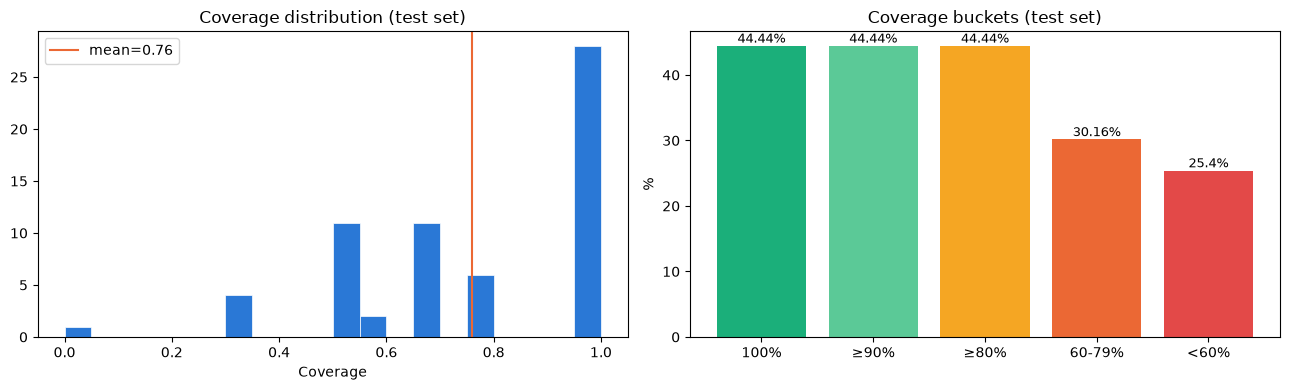

In [23]:
def summarize_coverage(df):
    c = df["coverage"]
    return {
        "mean_coverage":   round(c.mean()   * 100, 2),
        "median_coverage": round(c.median() * 100, 2),
        "min_coverage":    round(c.min()    * 100, 2),
        "max_coverage":    round(c.max()    * 100, 2),
        "std_coverage":    round(c.std()    * 100, 2),
        "pct_100":         round((c == 1.0).mean()                         * 100, 2),
        "pct_ge_90":       round((c >= 0.90).mean()                        * 100, 2),
        "pct_ge_80":       round((c >= 0.80).mean()                        * 100, 2),
        "pct_60_79":       round(((c >= 0.60) & (c < 0.80)).mean()         * 100, 2),
        "pct_lt_60":       round((c < 0.60).mean()                         * 100, 2),
    }

summary_rows = []
for split_name, df in coverage_by_split.items():
    row = {"split": split_name, "model": "yolov11l-seg", "conf_mode": CONF_MODE}
    row.update(summarize_coverage(df))
    summary_rows.append(row)

coverage_summary_df = pd.DataFrame(summary_rows)
coverage_summary_df.to_csv(DIRS["class_coverage"] / "coverage_summary.csv", index=False)
display(coverage_summary_df)

# ── Coverage distribution plot ────────────────────────────────────────────────
test_cov = coverage_by_split["test"]["coverage"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_cov, bins=20, color="#2a78d6", edgecolor="white", linewidth=0.5)
axes[0].axvline(test_cov.mean(), color="#eb6834", linewidth=1.5, label=f"mean={test_cov.mean():.2f}")
axes[0].set_xlabel("Coverage"); axes[0].set_title("Coverage distribution (test set)")
axes[0].legend()

labels_cov = ["pct_100", "pct_ge_90", "pct_ge_80", "pct_60_79", "pct_lt_60"]
test_summary = coverage_summary_df[coverage_summary_df["split"]=="test"].iloc[0]
vals   = [test_summary[k] for k in labels_cov]
clrs   = ["#1baf7a","#5bc997","#f5a623","#eb6834","#e34948"]
axes[1].bar(["100%", "≥90%", "≥80%", "60-79%", "<60%"], vals, color=clrs)
axes[1].set_ylabel("%"); axes[1].set_title("Coverage buckets (test set)")
for i, v in enumerate(vals):
    axes[1].text(i, v+0.5, f"{v}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(DIRS["class_coverage"] / "coverage_distribution.png", dpi=120)
plt.show()


## 6. Per-class presence coverage

=== TEST SET ===


,class_name,gt_images,detected_images,presence_coverage,miss_rate
8,sambal,8,2,25.00,75.00
12,tofu,7,2,28.57,71.43
11,tempeh,7,3,42.86,57.14
1,chicken,15,7,46.67,53.33
10,squid,4,2,50.00,50.00
3,fish,5,3,60.00,40.00
4,fruit,3,2,66.67,33.33
9,shrimp,4,3,75.00,25.00
0,beef,9,7,77.78,22.22
2,egg,19,15,78.95,21.05


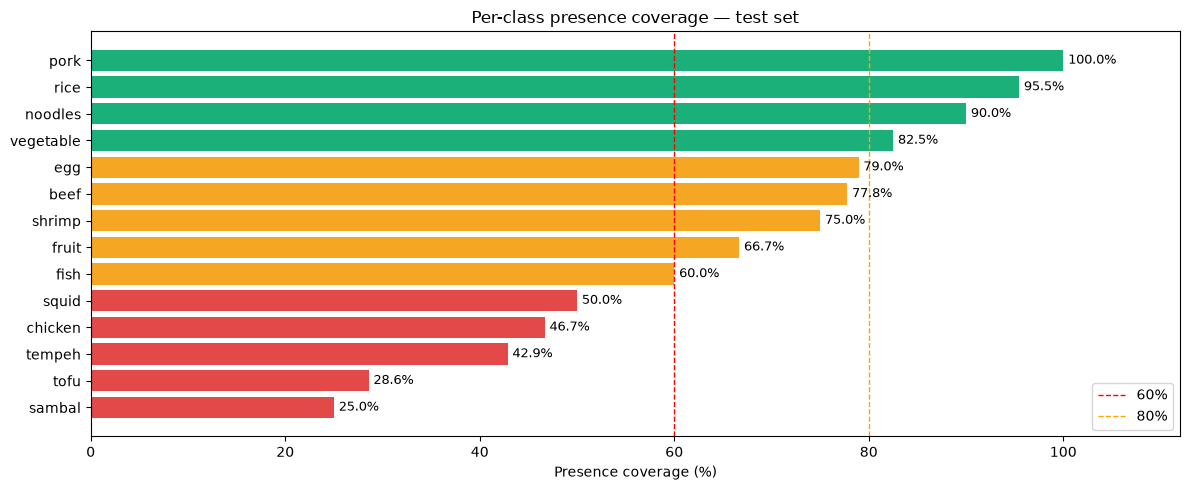

In [24]:
def compute_presence_coverage(coverage_df):
    rows = []
    for cls in class_names:
        gt_mask  = coverage_df["gt_classes"].apply(
            lambda s: cls in s.split(",") if s else False)
        n_gt = gt_mask.sum()
        if n_gt == 0:
            continue
        det_mask = gt_mask & coverage_df["pred_classes"].apply(
            lambda s: cls in s.split(",") if s else False)
        rows.append({
            "class_name":        cls,
            "gt_images":         int(n_gt),
            "detected_images":   int(det_mask.sum()),
            "presence_coverage": round(det_mask.sum() / n_gt * 100, 2),
            "miss_rate":         round((1 - det_mask.sum() / n_gt) * 100, 2),
        })
    return pd.DataFrame(rows).sort_values("presence_coverage")

presence_by_split = {}
for split_name, df in coverage_by_split.items():
    pres = compute_presence_coverage(df)
    presence_by_split[split_name] = pres
    pres.to_csv(DIRS["class_coverage"] / f"presence_coverage_{split_name}.csv", index=False)

print("=== TEST SET ===")
display(presence_by_split["test"])

# ── Presence coverage bar ─────────────────────────────────────────────────────
test_pres = presence_by_split["test"].sort_values("presence_coverage")
fig, ax   = plt.subplots(figsize=(12, 5))
colors    = ["#e34948" if v < 60 else "#f5a623" if v < 80 else "#1baf7a"
             for v in test_pres["presence_coverage"]]
bars = ax.barh(test_pres["class_name"], test_pres["presence_coverage"], color=colors)
for bar, v in zip(bars, test_pres["presence_coverage"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}%", va="center", fontsize=9)
ax.axvline(60, color="red",    linewidth=1, linestyle="--", label="60%")
ax.axvline(80, color="orange", linewidth=1, linestyle="--", label="80%")
ax.set_xlabel("Presence coverage (%)"); ax.set_xlim(0, 112)
ax.set_title("Per-class presence coverage — test set"); ax.legend()
plt.tight_layout()
plt.savefig(DIRS["class_coverage"] / "presence_coverage_per_class.png", dpi=120)
plt.show()


## 7. Missing-class analysis

In [25]:
def missing_class_analysis(coverage_df):
    miss  = {c: 0 for c in class_names}
    gt_ct = {c: 0 for c in class_names}
    for _, row in coverage_df.iterrows():
        for c in row["missing_classes"].split(","):
            if c: miss[c] += 1
        for c in row["gt_classes"].split(","):
            if c: gt_ct[c] += 1
    rows = []
    for c in class_names:
        gt_n   = gt_ct[c]
        miss_n = miss[c]
        rows.append({
            "class_name":          c,
            "times_in_gt":         gt_n,
            "times_missed":        miss_n,
            "miss_rate_pct":       round(miss_n / gt_n * 100, 2) if gt_n > 0 else None,
            "times_detected":      gt_n - miss_n,
        })
    return pd.DataFrame(rows).sort_values("miss_rate_pct", ascending=False, na_position="last")

missing_by_split = {}
for split_name, df in coverage_by_split.items():
    miss_df = missing_class_analysis(df)
    missing_by_split[split_name] = miss_df
    miss_df.to_csv(DIRS["class_coverage"] / f"missing_class_{split_name}.csv", index=False)

display(missing_by_split["test"])


,class_name,times_in_gt,times_missed,miss_rate_pct,times_detected
8,sambal,8,6,75.00,2
12,tofu,7,5,71.43,2
11,tempeh,7,4,57.14,3
1,chicken,15,8,53.33,7
10,squid,4,2,50.00,2
3,fish,5,2,40.00,3
4,fruit,3,1,33.33,2
9,shrimp,4,1,25.00,3
0,beef,9,2,22.22,7
2,egg,19,4,21.05,15


## 8. False-positive analysis

In [26]:
def false_positive_analysis(coverage_df):
    fp = {c: 0 for c in class_names}
    for fp_str in coverage_df["false_positive_classes"]:
        if not fp_str:
            continue
        for c in fp_str.split(","):
            if c: fp[c] += 1
    return pd.DataFrame(
        [{"class_name": c, "false_positive_count": n} for c, n in fp.items()]
    ).sort_values("false_positive_count", ascending=False)

fp_by_split = {}
for split_name, df in coverage_by_split.items():
    fp_df = false_positive_analysis(df)
    fp_by_split[split_name] = fp_df
    fp_df.to_csv(DIRS["class_coverage"] / f"false_positive_{split_name}.csv", index=False)

display(fp_by_split["test"])

# FP rate per image
total_fp   = fp_by_split["test"]["false_positive_count"].sum()
fp_rate    = round(total_fp / len(TEST_IMG_PATHS), 3)
print(f"\nTotal FP (test): {total_fp} | FP per image: {fp_rate}")


,class_name,false_positive_count
1,chicken,13
2,egg,8
13,vegetable,8
0,beef,7
6,pork,5
9,shrimp,4
4,fruit,2
5,noodles,2
11,tempeh,2
3,fish,1



Total FP (test): 54 | FP per image: 0.857


## 9. Instance-level performance (IoU matching)

In [27]:
def compute_instance_metrics(image_paths, labels_dir, conf=GLOBAL_CONF):
    tp = fp = fn = 0
    gt_total = pred_total = 0
    pc_tp = {c: 0 for c in class_names}
    pc_fp = {c: 0 for c in class_names}
    pc_fn = {c: 0 for c in class_names}

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"
        gt_annos   = load_gt_annotations(label_path)
        preds      = run_prediction(image_path, conf=conf)
        gt_total   += len(gt_annos)
        pred_total += len(preds)
        matched_gt = set()
        for p in preds:
            best_iou, best_idx = 0.0, -1
            for idx, g in enumerate(gt_annos):
                if idx in matched_gt or g["class_name"] != p["class_name"]:
                    continue
                iou = polygon_iou(p["polygon"], g["polygon"])
                if iou > best_iou:
                    best_iou, best_idx = iou, idx
            if best_iou >= IOU_MATCH:
                tp += 1; pc_tp[p["class_name"]] += 1; matched_gt.add(best_idx)
            else:
                fp += 1; pc_fp[p["class_name"]] += 1
        for idx, g in enumerate(gt_annos):
            if idx not in matched_gt:
                fn += 1; pc_fn[g["class_name"]] += 1

    inst_prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    inst_rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    overall = {
        "gt_instances":   gt_total,
        "pred_instances": pred_total,
        "tp": tp, "fp": fp, "fn": fn,
        "instance_precision": round(inst_prec, 4),
        "instance_recall":    round(inst_rec,  4),
    }
    pc_rows = []
    for c in class_names:
        c_tp, c_fp, c_fn = pc_tp[c], pc_fp[c], pc_fn[c]
        prec = round(c_tp / (c_tp + c_fp), 4) if (c_tp + c_fp) > 0 else None
        rec  = round(c_tp / (c_tp + c_fn), 4) if (c_tp + c_fn) > 0 else None
        pc_rows.append({
            "class_name":         c,
            "gt_instances":       c_tp + c_fn,
            "pred_instances":     c_tp + c_fp,
            "instance_precision": prec,
            "instance_recall":    rec,
        })
    return overall, pd.DataFrame(pc_rows)

print("Computing instance-level metrics (test set) — bisa beberapa menit ...")
inst_overall, inst_per_class = compute_instance_metrics(TEST_IMG_PATHS, TEST_LABELS_DIR)
inst_per_class.to_csv(DIRS["instance"] / "instance_per_class_test.csv", index=False)

print("\nOverall instance metrics (test):")
for k, v in inst_overall.items():
    print(f"  {k}: {v}")
print()
display(inst_per_class.sort_values("instance_recall", na_position="last"))


Computing instance-level metrics (test set) — bisa beberapa menit ...

Overall instance metrics (test):
  gt_instances: 751
  pred_instances: 404
  tp: 245
  fp: 159
  fn: 506
  instance_precision: 0.6064
  instance_recall: 0.3262



,class_name,gt_instances,pred_instances,instance_precision,instance_recall
12,tofu,55,5,0.6000,0.0545
8,sambal,27,2,1.0000,0.0741
1,chicken,38,27,0.2222,0.1579
11,tempeh,19,6,0.5000,0.1579
10,squid,18,5,0.6000,0.1667
6,pork,88,25,0.7600,0.2159
13,vegetable,222,99,0.5253,0.2342
0,beef,17,22,0.2727,0.3529
3,fish,11,7,0.7143,0.4545
2,egg,36,30,0.6000,0.5000


## 10. Qualitative samples — visualisasi prediksi

In [28]:
from shapely.geometry import MultiPolygon, Polygon

def get_largest_polygon(geom):
    """Ambil polygon terbesar dari Polygon atau MultiPolygon."""
    if geom is None:
        return None
    if isinstance(geom, MultiPolygon):
        return max(geom.geoms, key=lambda g: g.area)
    return geom

def visualize_predictions(image_paths, labels_dir, n=16, cols=4, conf=GLOBAL_CONF, title=""):
    sample = image_paths[:n]
    rows_count = math.ceil(len(sample) / cols)
    fig, axes  = plt.subplots(rows_count, cols, figsize=(cols * 4, rows_count * 4))
    axes       = np.atleast_1d(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, image_path in zip(axes, sample):
        label_path = labels_dir / f"{image_path.stem}.txt"
        gt_annos   = load_gt_annotations(label_path)
        preds      = run_prediction(image_path, conf=conf)
        with Image.open(image_path).convert("RGB") as img:
            w, h = img.size
            ax.imshow(img)
        for g in gt_annos:
            poly = get_largest_polygon(g["polygon"])
            if poly is None:
                continue
            pts = np.asarray(poly.exterior.coords) * np.array([w, h])
            ax.plot(np.append(pts[:, 0], pts[0, 0]),
                    np.append(pts[:, 1], pts[0, 1]),
                    "g-", linewidth=1.5, alpha=0.8)
        for p in preds:
            poly = get_largest_polygon(p["polygon"])
            if poly is None:
                continue
            pts = np.asarray(poly.exterior.coords) * np.array([w, h])
            ax.plot(np.append(pts[:, 0], pts[0, 0]),
                    np.append(pts[:, 1], pts[0, 1]),
                    "r--", linewidth=1.5, alpha=0.8)
            ax.text(pts[0, 0], pts[0, 1],
                    f"{p['class_name']} {p['confidence']:.2f}",
                    color="white", fontsize=7,
                    bbox={"facecolor": "red", "alpha": 0.5, "pad": 1})
        gt_cls = sorted(set(g["class_name"] for g in gt_annos))
        pred_cls = sorted(set(p["class_name"] for p in preds))
        miss  = set(gt_cls) - set(pred_cls)
        cov   = len(set(gt_cls) & set(pred_cls)) / len(gt_cls) if gt_cls else 1.0
        color = "green" if cov == 1.0 else "orange" if cov >= 0.7 else "red"
        ax.set_title(f"{image_path.stem[:20]}\ncov={cov:.0%}"
                     + (f"  miss:{','.join(miss)}" if miss else ""),
                     fontsize=8, color=color)
    patches = [
        mpatches.Patch(color="green", label="GT mask"),
        mpatches.Patch(color="red",   label="Prediction"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=2, fontsize=10)
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    safe_title = title.replace(" ", "_").replace("/", "-")
    plt.savefig(DIRS["qualitative"] / f"samples_{safe_title}.png", dpi=100, bbox_inches="tight")
    plt.show()

## 11. Go / No-Go verdict

In [29]:
# ── Kumpulkan semua metrik ────────────────────────────────────────────────────
test_overall  = overall_rows["test"]
test_cov_sum  = coverage_summary_df[coverage_summary_df["split"]=="test"].iloc[0]
test_pres     = presence_by_split["test"]
test_fp_rate  = round(fp_by_split["test"]["false_positive_count"].sum() / len(TEST_IMG_PATHS), 3)

mean_coverage   = test_cov_sum["mean_coverage"]
pct_ge_90       = test_cov_sum["pct_ge_90"]
pct_lt_60       = test_cov_sum["pct_lt_60"]
mask_recall     = test_overall["mask_recall"]
mask_map        = test_overall["mask_mAP50-95"]
worst_pres      = test_pres["presence_coverage"].min()
worst_cls       = test_pres.loc[test_pres["presence_coverage"].idxmin(), "class_name"]

# ── Threshold targets ─────────────────────────────────────────────────────────
targets = {
    "mean_coverage ≥ 85%":   (mean_coverage >= 85,   f"{mean_coverage:.1f}%"),
    "pct_ge_90 ≥ 60%":       (pct_ge_90 >= 60,       f"{pct_ge_90:.1f}%"),
    "pct_lt_60 ≤ 10%":       (pct_lt_60 <= 10,       f"{pct_lt_60:.1f}%"),
    "mask_recall ≥ 0.40":    (mask_recall >= 0.40,   f"{mask_recall:.4f}"),
    "mask_mAP50-95 ≥ 0.25":  (mask_map >= 0.25,      f"{mask_map:.4f}"),
    "worst class pres ≥ 50%": (worst_pres >= 50,     f"{worst_cls}: {worst_pres:.1f}%"),
    "FP/image ≤ 5":           (test_fp_rate <= 5,    f"{test_fp_rate}"),
}

print("=" * 60)
print("GO / NO-GO CHECKLIST — YOLOv11l-seg final")
print("=" * 60)
all_pass = True
for criterion, (passed, value) in targets.items():
    status = "✅ PASS" if passed else "❌ FAIL"
    if not passed:
        all_pass = False
    print(f"{status}  {criterion:<30s}  actual: {value}")

print("=" * 60)
if all_pass:
    print("✅  GO — model siap keluar lab dan masuk src/")
else:
    print("⚠️   NO-GO — perbaiki item yang FAIL sebelum lanjut ke src/")
print("=" * 60)

# ── Save full summary JSON ────────────────────────────────────────────────────
final_summary = {
    "model":          "yolov11l-seg",
    "model_path":     str(MODEL_PATH),
    "conf_mode":      CONF_MODE,
    "global_conf":    GLOBAL_CONF,
    "evaluated_on":   "test set (held-out)",
    "n_test_images":  len(TEST_IMG_PATHS),
    "overall":        {k: v for k, v in test_overall.items()},
    "coverage":       {k: v for k, v in test_cov_sum.items()},
    "instance":       inst_overall,
    "fp_per_image":   test_fp_rate,
    "go_nogo": {
        "all_pass": all_pass,
        "checks":   {k: {"pass": v[0], "value": v[1]} for k, v in targets.items()},
    },
}
summary_path = DIRS["summary"] / "final_evaluation_summary.json"
summary_path.write_text(json.dumps(final_summary, indent=2, default=str))
print(f"\nSummary saved → {summary_path}")


GO / NO-GO CHECKLIST — YOLOv11l-seg final
❌ FAIL  mean_coverage ≥ 85%             actual: 76.0%
❌ FAIL  pct_ge_90 ≥ 60%                 actual: 44.4%
❌ FAIL  pct_lt_60 ≤ 10%                 actual: 25.4%
❌ FAIL  mask_recall ≥ 0.40              actual: 0.3390
✅ PASS  mask_mAP50-95 ≥ 0.25            actual: 0.2628
❌ FAIL  worst class pres ≥ 50%          actual: sambal: 25.0%
✅ PASS  FP/image ≤ 5                    actual: 0.857
⚠️   NO-GO — perbaiki item yang FAIL sebelum lanjut ke src/

Summary saved → D:\PREP_INTERN\nutrivision_pro\results\v2_final\summary\final_evaluation_summary.json


---
## Output artifact structure

```
results/final_evaluation/
├── metrics/
│   └── overall_metrics.csv            # val + test, mask & box
├── per_class/
│   ├── per_class_val.csv
│   ├── per_class_test.csv
│   └── recall_per_class.png
├── class_coverage/
│   ├── image_coverage_val.csv
│   ├── image_coverage_test.csv
│   ├── coverage_summary.csv
│   ├── coverage_distribution.png
│   ├── presence_coverage_val.csv
│   ├── presence_coverage_test.csv
│   ├── presence_coverage_per_class.png
│   ├── missing_class_val.csv
│   ├── missing_class_test.csv
│   ├── false_positive_val.csv
│   └── false_positive_test.csv
├── instance/
│   └── instance_per_class_test.csv
├── qualitative/
│   ├── samples_test_set_random.png
│   └── samples_test_set_worst_coverage.png
└── summary/
    └── final_evaluation_summary.json  ← go/no-go verdict
```
